In [2]:
pip install --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import pandas_datareader as Data

In [36]:
# start = '2015-01-01'
# end = '2024-12-31'
# # df = Data.DataReader('AAPL', 'yahoo',start,end)

In [37]:
import yfinance as yf
import pandas as pd

# Define date range
start = '2015-01-01'
end = '2024-12-31'

# Download AAPL data
df = yf.download('AAPL', start=start, end=end)

# Display the first few rows
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.320429  24.789798  23.879978  24.778675  212818400
2015-01-05  23.635284  24.169164  23.448427  24.089082  257142000
2015-01-06  23.637514  23.897780  23.274920  23.699800  263188400
2015-01-07  23.968958  24.069060  23.735385  23.846610  160423600
2015-01-08  24.889900  24.947738  24.180285  24.298185  237458000


In [38]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,254.989655,255.369227,253.171646,254.490204,40858800
2024-12-24,257.916443,257.926411,255.009620,255.209412,23234700
2024-12-26,258.735504,259.814335,257.347047,257.906429,27237100
2024-12-27,255.309296,258.415896,252.782075,257.546826,42355300
2024-12-30,251.923019,253.221595,250.474615,251.952985,35557500


In [39]:
# df = df.drop(['Date'], axis =1)

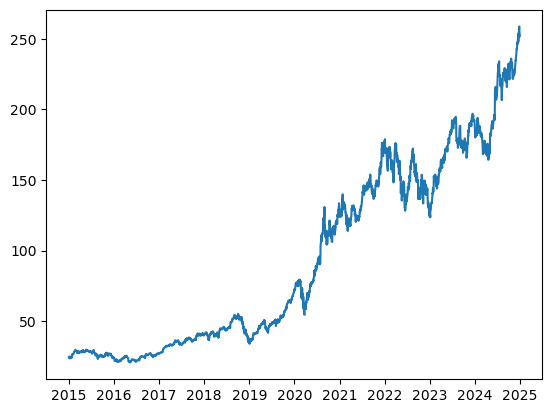

In [40]:
plt.plot(df.Close)

In [41]:
ma100 = df.Close.rolling(100).mean()

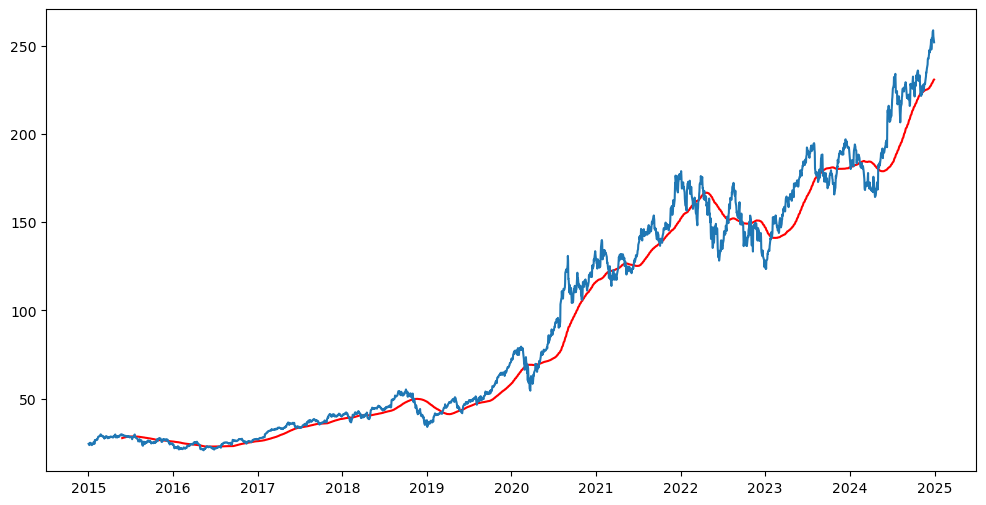

In [42]:
plt.figure(figsize=(12,6))
plt.plot(ma100, 'r')
plt.plot(df.Close)

In [43]:
ma200 = df.Close.rolling(200).mean()


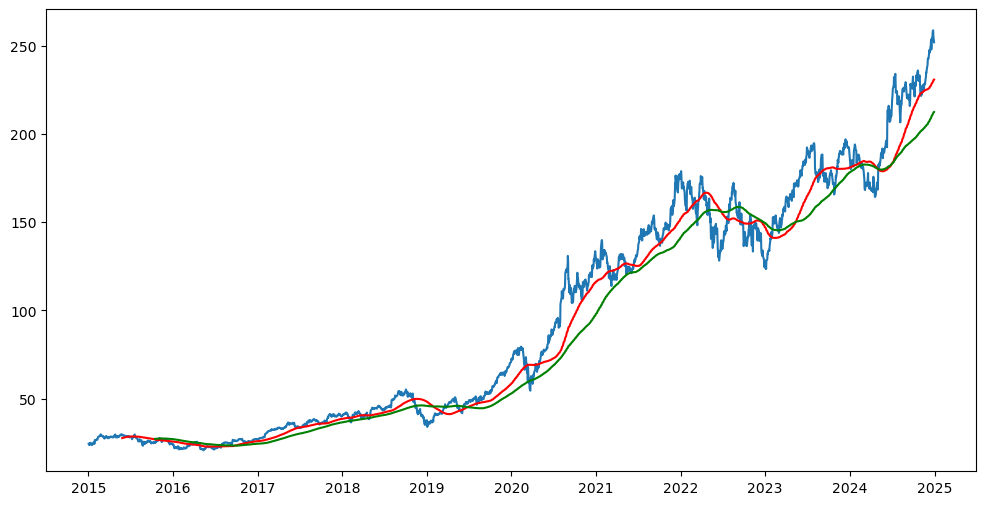

In [44]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200 , 'g')

In [45]:
df.shape

(2515, 5)

In [46]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.7):len(df)])

In [47]:

print(data_training)

print(data_testing)

Ticker            AAPL
Date                  
2015-01-02   24.320429
2015-01-05   23.635284
2015-01-06   23.637514
2015-01-07   23.968958
2015-01-08   24.889900
...                ...
2021-12-21  170.015030
2021-12-22  172.619492
2021-12-23  173.248474
2021-12-27  177.228806
2021-12-28  176.206680

[1760 rows x 1 columns]
Ticker            AAPL
Date                  
2021-12-29  176.295197
2021-12-30  175.135437
2021-12-31  174.516266
2022-01-03  178.879883
2022-01-04  176.609619
...                ...
2024-12-23  254.989655
2024-12-24  257.916443
2024-12-26  258.735504
2024-12-27  255.309296
2024-12-30  251.923019

[755 rows x 1 columns]


In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range= (0,1))

In [49]:
data_training_array = scaler.fit_transform(data_training)

In [50]:
data_training_array

array([[0.02328839],
       [0.01891199],
       [0.01892623],
       ...,
       [0.97457539],
       [1.        ],
       [0.99347111]])

In [51]:
data_training_array.shape

(1760, 1)

In [52]:
x_train = []
y_train= []

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100 : i])
    y_train.append(data_training_array[i,0])

In [53]:
x_train,y_train = np.array(x_train), np.array(y_train)

In [54]:
x_train.shape

(1660, 100, 1)

In [55]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [56]:
model = Sequential()
model.add(LSTM(units= 50, activation= 'relu',return_sequences=True, 
              input_shape = (x_train.shape[1],1)))
model. add (Dropout (0.2))

model.add(LSTM(units= 60, activation= 'relu',return_sequences=True))
model. add (Dropout (0.3))


model.add(LSTM(units= 60, activation= 'relu',return_sequences=True))
model. add (Dropout (0.4))

model.add(LSTM(units= 120, activation= 'relu',return_sequences=True))
model. add (Dropout (0.5))

model.add(Dense(units =1))

/Users/yashshah/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 100, 60)        │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 100, 120)       │        86,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100, 1)         │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,081 (597.97 KB)

 Trainable params: 153,081 (597.97 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0893
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0716
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0701
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0690
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0672
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0663
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0666
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0673
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0667
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0665
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0675
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0660
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0654
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0656
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0638
Epoc

In [59]:
model.save('keras_model.h5')

In [60]:
data_testing.head()

Ticker,AAPL
Date,
2021-12-29,176.295197
2021-12-30,175.135437
2021-12-31,174.516266
2022-01-03,178.879883
2022-01-04,176.609619
